# Principal component analysis — experiments

Companion notebook to the post. The experiments are numerical illustrations of the
viewpoints described there. All of them reduce to the eigendecomposition of the
sample covariance matrix, or equivalently the SVD of the centered data matrix.

1. **Eigendecomposition and projection** — compute principal axes from the covariance
   matrix and project two-dimensional data onto the first axis.
2. **Equivalence with SVD** — verify that the SVD of the centered data gives the same
   axes and that eigenvalues equal the squared singular values divided by $n$.
3. **Decorrelation and variance ordering** — confirm that the projected coordinates
   are uncorrelated and that their variances are the eigenvalues.
4. **Reconstruction error** — confirm that the mean squared reconstruction error from
   $q$ components equals the sum of the discarded eigenvalues.
5. **Distance preservation (MDS view)** — compare pairwise distances before and after
   projection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- site theme -----------------------------------------------------------
BG, PANEL, LINE = "#0e1116", "#151a21", "#222a35"
FG, MUTED, ACCENT, ACCENT2 = "#d7dde6", "#8a94a3", "#4aa3ff", "#e0a458"
mpl.rcParams.update({
    "figure.facecolor": PANEL, "axes.facecolor": PANEL, "savefig.facecolor": PANEL,
    "axes.edgecolor": LINE, "axes.labelcolor": FG, "text.color": FG,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": LINE,
    "axes.grid": True, "grid.linewidth": 0.6, "grid.alpha": 0.7,
    "font.family": "monospace", "font.size": 11, "figure.dpi": 120,
    "axes.titlesize": 12, "legend.frameon": False, "legend.labelcolor": FG,
})

def style(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(LINE)
    return ax

rng = np.random.default_rng(1)

## 1. Eigendecomposition and projection

PCA centers the data, forms the sample covariance matrix
$\Sigma = \tfrac{1}{n}\sum_i (X_i-\bar X)(X_i-\bar X)^\top$, and takes its eigenvectors as the
principal axes. The projection onto the first axis is the best one-dimensional linear
approximation of the data.

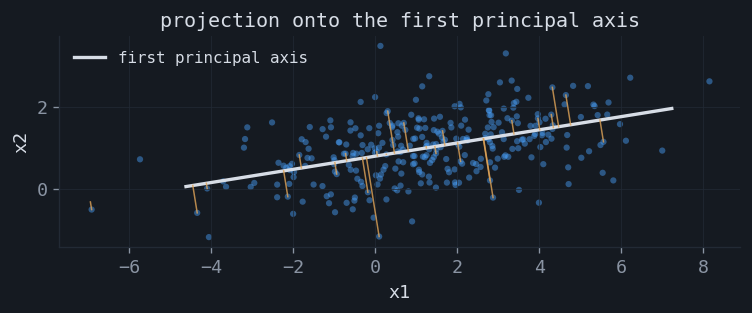

eigenvalues: [5.563 0.446]


In [2]:
mean = np.array([1.5, 1.0])
A = np.array([[2.2, 1.3], [0.0, 0.8]])
X = rng.standard_normal((300, 2)) @ A.T + mean
Xc = X - X.mean(0)

Sigma = (Xc.T @ Xc) / len(Xc)
evals, evecs = np.linalg.eigh(Sigma)
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]
e1 = evecs[:, 0]; mu = X.mean(0)

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.scatter(X[:, 0], X[:, 1], s=14, color=ACCENT, alpha=0.45, edgecolors="none")
t = np.linspace(-6, 6, 2); line = mu[None, :] + t[:, None] * e1[None, :]
ax.plot(line[:, 0], line[:, 1], color=FG, lw=2.0, label="first principal axis")
for i in range(0, 300, 12):
    proj = mu + ((X[i]-mu) @ e1) * e1
    ax.plot([X[i,0], proj[0]], [X[i,1], proj[1]], color=ACCENT2, lw=0.9, alpha=0.8)
ax.set_aspect("equal"); ax.set_xlabel("x1"); ax.set_ylabel("x2")
ax.set_title("projection onto the first principal axis"); ax.legend(fontsize=9.5); style(ax)
plt.tight_layout(); plt.show()
print("eigenvalues:", np.round(evals, 3))

## 2. Equivalence with the SVD

If the centered data matrix is $\bar{\mathbf X} = U \Lambda V^\top$, then the principal axes
are the columns of $U$ and the covariance eigenvalues are the squared singular values
divided by $n$. The check below compares the two computations.

In [3]:
# centered data matrix with observations as columns (p x n), as in the lecture
Xbar = Xc.T
U, s, Vt = np.linalg.svd(Xbar, full_matrices=False)
eig_from_svd = s**2 / len(Xc)

print("eigenvalues from covariance:", np.round(evals, 4))
print("eigenvalues from SVD       :", np.round(eig_from_svd, 4))
# axes match up to sign
align = np.abs(U[:, :2].T @ evecs[:, :2])
print("|U^T E| (identity up to sign):\n", np.round(align, 3))

eigenvalues from covariance: [5.5632 0.446 ]
eigenvalues from SVD       : [5.5632 0.446 ]
|U^T E| (identity up to sign):
 [[1. 0.]
 [0. 1.]]


## 3. Decorrelation and variance ordering

Projecting the centered data onto the eigenvectors yields coordinates whose covariance
matrix is diagonal, with the eigenvalues on the diagonal. The components are therefore
uncorrelated and ordered by variance.

covariance of projected coordinates:
 [[5.5632 0.    ]
 [0.     0.446 ]]
diagonal equals eigenvalues: True
off-diagonal near zero     : True


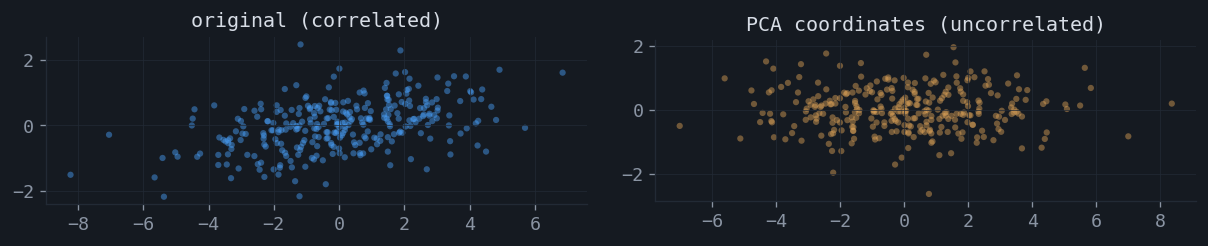

In [4]:
Y = Xc @ evecs
covY = (Y.T @ Y) / len(Y)
print("covariance of projected coordinates:\n", np.round(covY, 4))
print("diagonal equals eigenvalues:", np.allclose(np.diag(covY), evals))
print("off-diagonal near zero     :", np.allclose(covY - np.diag(np.diag(covY)), 0, atol=1e-9))

fig, (a, b) = plt.subplots(1, 2, figsize=(10.2, 4.4))
a.scatter(Xc[:, 0], Xc[:, 1], s=14, color=ACCENT, alpha=0.45, edgecolors="none")
a.set_title("original (correlated)"); a.set_aspect("equal"); style(a)
b.scatter(Y[:, 0], Y[:, 1], s=14, color=ACCENT2, alpha=0.45, edgecolors="none")
b.set_title("PCA coordinates (uncorrelated)"); b.set_aspect("equal"); style(b)
plt.tight_layout(); plt.show()

## 4. Reconstruction error

Keeping the first $q$ components and reconstructing gives a mean squared error equal to
the sum of the discarded eigenvalues, $\sum_{k>q}\lambda_k$. The retained fraction of
variance is $\sum_{k\le q}\lambda_k / \sum_k \lambda_k$.

q | empirical MSE | sum of discarded eigenvalues
 1 |       9.1302 | 9.1325
 2 |       4.6507 | 4.6519
 3 |       2.6777 | 2.6784
 4 |       1.5771 | 1.5775
 5 |       0.9073 | 0.9075
 6 |       0.5134 | 0.5135
 7 |       0.2603 | 0.2604
 8 |       0.1059 | 0.1060
 9 |       0.0295 | 0.0295
10 |       0.0000 | 0.0000


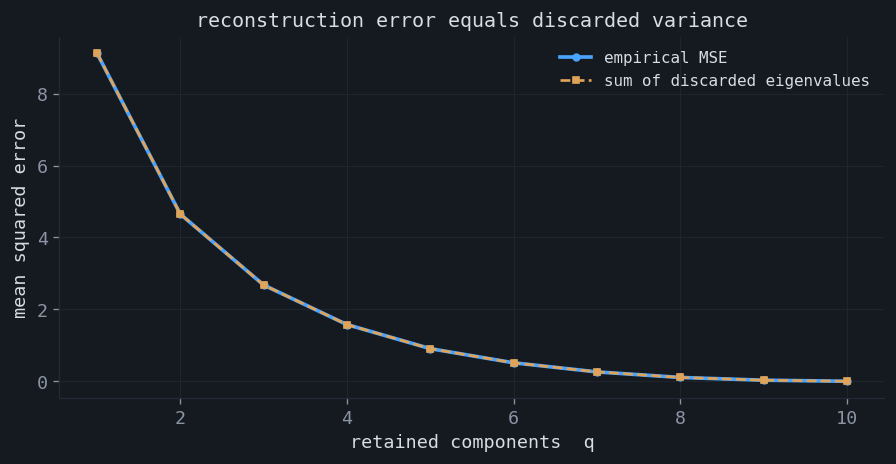

In [5]:
p = 10
spectrum = np.array([8.0, 4.5, 2.0, 1.1, 0.7, 0.4, 0.25, 0.15, 0.08, 0.03])
Q = np.linalg.qr(rng.standard_normal((p, p)))[0]
cov = Q @ np.diag(spectrum) @ Q.T
data = rng.multivariate_normal(np.zeros(p), cov, size=4000)
dc = data - data.mean(0)

ev, V = np.linalg.eigh(np.cov(dc.T))
ev = ev[::-1]; V = V[:, ::-1]
total = ev.sum()

errs_empirical, errs_theory = [], []
for q in range(1, p+1):
    Vq = V[:, :q]
    recon = dc @ Vq @ Vq.T
    errs_empirical.append(np.mean(np.sum((dc - recon)**2, axis=1)))
    errs_theory.append(ev[q:].sum())

q = np.arange(1, p+1)
print("q | empirical MSE | sum of discarded eigenvalues")
for i in range(p):
    print(f"{q[i]:2d} | {errs_empirical[i]:12.4f} | {errs_theory[i]:.4f}")

fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.plot(q, errs_empirical, color=ACCENT, lw=2.2, marker="o", ms=4, label="empirical MSE")
ax.plot(q, errs_theory, color=ACCENT2, lw=1.6, ls="--", marker="s", ms=4, label="sum of discarded eigenvalues")
ax.set_xlabel("retained components  q"); ax.set_ylabel("mean squared error")
ax.set_title("reconstruction error equals discarded variance"); ax.legend(fontsize=9.5); style(ax)
plt.tight_layout(); plt.show()

## 5. Distance preservation

The metric MDS view states that PCA preserves pairwise Euclidean distances as well as
possible for a linear projection. For data that is close to two-dimensional, the
distances after a two-dimensional projection match the original distances closely.

correlation between original and projected distances: 0.9990


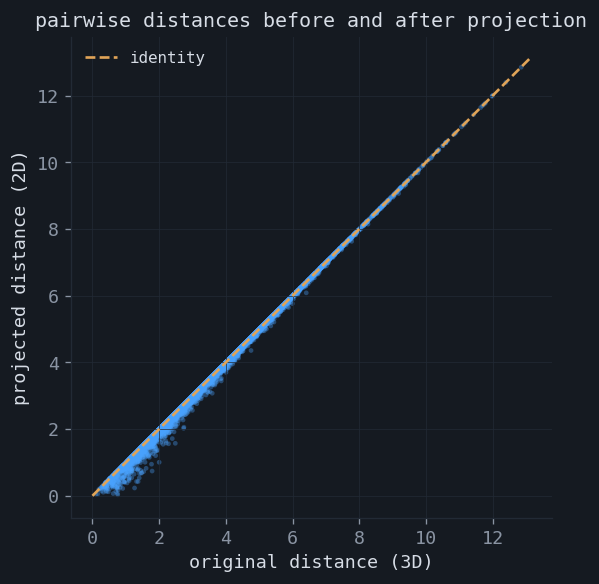

In [6]:
from itertools import combinations
spectrum3 = np.array([6.0, 3.0, 0.15])
Q3 = np.linalg.qr(rng.standard_normal((3, 3)))[0]
X3 = rng.multivariate_normal(np.zeros(3), Q3 @ np.diag(spectrum3) @ Q3.T, size=120)
X3c = X3 - X3.mean(0)
ev3, V3 = np.linalg.eigh(np.cov(X3c.T)); V3 = V3[:, ::-1]
Y2 = X3c @ V3[:, :2]

idx = list(combinations(range(120), 2))
dh = np.array([np.linalg.norm(X3c[i]-X3c[j]) for i, j in idx])
dl = np.array([np.linalg.norm(Y2[i]-Y2[j]) for i, j in idx])
print(f"correlation between original and projected distances: {np.corrcoef(dh, dl)[0,1]:.4f}")

fig, ax = plt.subplots(figsize=(6.4, 5.0))
ax.scatter(dh, dl, s=8, color=ACCENT, alpha=0.35, edgecolors="none")
lims = [0, max(dh.max(), dl.max())*1.02]
ax.plot(lims, lims, color=ACCENT2, lw=1.6, ls="--", label="identity")
ax.set_xlabel("original distance (3D)"); ax.set_ylabel("projected distance (2D)")
ax.set_aspect("equal"); ax.set_title("pairwise distances before and after projection")
ax.legend(fontsize=9.5); style(ax)
plt.tight_layout(); plt.show()

## Summary

- The principal axes are the eigenvectors of the sample covariance matrix; the
  eigenvalues are the variances along those axes.
- The SVD of the centered data matrix produces the same axes, with eigenvalues equal to
  the squared singular values divided by $n$.
- The projected coordinates are uncorrelated and ordered by variance.
- The mean squared reconstruction error from $q$ components equals the sum of the
  discarded eigenvalues, which is the basis for choosing $q$.
- The projection preserves pairwise Euclidean distances as well as a linear map can.